#Group Information

*   **Student ID:** 20520278
*   **Full Name:** Phạm Hoàng Phúc

---

*   **Student ID:** 20521446
*   **Full Name:** Huỳnh Nguyễn Vân Khánh

---

*   **Student ID:** 20521641
*   **Full Name:** Nguyễn Thị Ngọc Nga
---
*   **Student ID:** 20521663
*   **Full Name:** Nguyễn Đặng Bảo Ngọc
---
*   **Student ID:** 20521775
*   **Full Name:** Lê Trần Hữu Phước

# Download dataset

In [ ]:
! pip install -q kaggle

In [ ]:
import gdown

output = 'kaggle.json'
id = '16xa5C8CRS-PivDT6vJAxoMIMD4OIUlm4'
gdown.download(id=id, output=output) # Download data

Downloading...
From: https://drive.google.com/uc?id=16xa5C8CRS-PivDT6vJAxoMIMD4OIUlm4
To: /content/kaggle.json
100%|██████████| 71.0/71.0 [00:00<00:00, 172kB/s]


'kaggle.json'

In [ ]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# ! kaggle datasets download 'clkmuhammed/creditscoreclassification'
! kaggle datasets download 'parisrohan/credit-score-classification'

  0% 0.00/9.51M [00:00<?, ?B/s]
100% 9.51M/9.51M [00:00<00:00, 131MB/s]


In [ ]:
# !unzip creditscoreclassification.zip
!unzip credit-score-classification.zip

Archive:  credit-score-classification.zip
  inflating: test.csv                
  inflating: train.csv               


# Import libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                            precision_recall_fscore_support,
                            f1_score, recall_score,
                            precision_score)
import matplotlib.pyplot as plt
import scipy.stats as stats
import re
import seaborn as sns

#Cleaning data

## Load data

In [ ]:
df_train = pd.read_csv("train.csv")
print(df_train.shape)
df_train.info()

<ipython-input-8-ac029fb29d1b>:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("train.csv")


(100000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 

In [ ]:
df_test = pd.read_csv("test.csv")
print(df_test.shape)
df_test.info()

(50000, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 

In [ ]:
df = pd.concat([df_train, df_test], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  object 
 1   Customer_ID               150000 non-null  object 
 2   Month                     150000 non-null  object 
 3   Name                      135000 non-null  object 
 4   Age                       150000 non-null  object 
 5   SSN                       150000 non-null  object 
 6   Occupation                150000 non-null  object 
 7   Annual_Income             150000 non-null  object 
 8   Monthly_Inhand_Salary     127500 non-null  float64
 9   Num_Bank_Accounts         150000 non-null  int64  
 10  Num_Credit_Card           150000 non-null  int64  
 11  Interest_Rate             150000 non-null  int64  
 12  Num_of_Loan               150000 non-null  object 
 13  Type_of_Loan              132888 non-null  o

## Fixing data type

In [ ]:
def text_cleaning(data):
    if data is np.NaN or not isinstance(data, str):
        return data
    else:
        return str(data).strip('_ ,"')

def Month_Converter(x):
    if pd.notnull(x):
        num1 = int(x.split(' ')[0])
        num2 = int(x.split(' ')[3])

        return (num1*12)+num2
    else:
        return x

def get_Diff_Values_Colum(df_column, diff_value=[], sep=',', replace=''):
    column = df_column.dropna()
    for i in column:
        if sep not in i and i not in diff_value:
            diff_value.append(i)
        else:
            for data in map(lambda x:x.strip(), re.sub(replace, '', i).split(sep)):
                if not data in diff_value:
                    diff_value.append(data)
    return dict(enumerate(sorted(diff_value)))

In [ ]:
df = df.applymap(text_cleaning).replace(['', 'nan', '!@9#%8', '#F%$D@*&8'], np.NaN)

In [ ]:
df['ID']                      = df.ID.apply(lambda x: int(x, 16))
df['Customer_ID']             = df.Customer_ID.apply(lambda x: int(x[4:], 16))
df['Month']                   = pd.to_datetime(df.Month, format='%B').dt.month
df['Age']                     = df.Age.astype(int)
df['SSN']                     = df.SSN.apply(lambda x: x if x is np.NaN else int(str(x).replace('-', ''))).astype(float)
df['Annual_Income']           = df.Annual_Income.astype(float)
df['Num_of_Loan']             = df.Num_of_Loan.astype(int)
df['Num_of_Delayed_Payment']  = df.Num_of_Delayed_Payment.astype(float)
df['Changed_Credit_Limit']    = df.Changed_Credit_Limit.astype(float)
df['Outstanding_Debt']        = df.Outstanding_Debt.astype(float)
df['Amount_invested_monthly'] = df.Amount_invested_monthly.astype(float)
df['Monthly_Balance']         = df.Monthly_Balance.astype(float)

In [ ]:
df['Credit_History_Age'] = df.Credit_History_Age.apply(lambda x: Month_Converter(x)).astype(float)
df['Type_of_Loan'] = (df['Type_of_Loan']
                      .apply(lambda x: x.lower()
                      .replace('and ', '')
                      .replace(', ', ',').strip() if pd.notna(x) else x))

In [ ]:
get_Diff_Values_Colum(df['Type_of_Loan'])

{0: 'auto loan',
 1: 'credit-builder loan',
 2: 'debt consolidation loan',
 3: 'home equity loan',
 4: 'mortgage loan',
 5: 'not specified',
 6: 'payday loan',
 7: 'personal loan',
 8: 'student loan'}

## Replace invalid value with NaN and replace them with mode value

In [ ]:
def fill_nan_feature(df, column_name):
  most_common_names = df.groupby('Customer_ID')[column_name].agg(lambda x: x.mode()[0] if pd.notna(x).any() else np.NaN)

  # Replace NaN values with the most common name for each ID
  df[column_name] = df.apply(lambda row: most_common_names[row['Customer_ID']] if pd.isna(row[column_name]) else row[column_name], axis=1)

In [ ]:
df['Type_of_Loan'].replace([np.NaN], 'No Data', inplace=True)

In [ ]:
fill_nan_feature(df, 'Payment_Behaviour')
fill_nan_feature(df, 'Name')
fill_nan_feature(df, 'Occupation')
fill_nan_feature(df, 'Type_of_Loan')
fill_nan_feature(df, 'Credit_Mix')
fill_nan_feature(df, 'Payment_of_Min_Amount')

In [ ]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265.0,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265.0,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265.0,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,-500,821000265.0,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,267.0,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265.0,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,268.0,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265.0,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269.0,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  int64  
 1   Customer_ID               150000 non-null  int64  
 2   Month                     150000 non-null  int64  
 3   Name                      150000 non-null  object 
 4   Age                       150000 non-null  int64  
 5   SSN                       141600 non-null  float64
 6   Occupation                150000 non-null  object 
 7   Annual_Income             150000 non-null  float64
 8   Monthly_Inhand_Salary     127500 non-null  float64
 9   Num_Bank_Accounts         150000 non-null  int64  
 10  Num_Credit_Card           150000 non-null  int64  
 11  Interest_Rate             150000 non-null  int64  
 12  Num_of_Loan               150000 non-null  int64  
 13  Type_of_Loan              150000 non-null  o

In [ ]:
# Identify Wrong values Range
def get_group_min_max(df, groupby, column):
    cur = df[df[column].notna()].groupby(groupby)[column].apply(list);
    x, y = cur.apply(lambda x: stats.mode(x, keepdims=True)).apply([min, max])
    return x[0][0], y[0][0]

# Assigning Wrong values
def make_group_NaN_and_fill_mode_numeric(df, groupby, column, inplace=True):
    df_dropped = df[df[column].notna()].groupby(groupby)[column].apply(list);
    x, y = df_dropped.apply(lambda x: stats.mode(x, keepdims=True)).apply([min, max])
    mini, maxi = x[0][0], y[0][0]

    # assign Wrong Values to NaN
    col = df[column].apply(lambda x: np.NaN if ((x<mini)|(x>maxi)) else x)

    # fill with local mode
    mode_by_group = df.groupby(groupby)[column].transform(lambda x: x.mode()[0] if not x.mode().empty else np.NaN)
    result = col.fillna(mode_by_group)

    # inplace
    if inplace:
        df[column]=result
    else:
        return result


# Reassign Wrong Values and Show Function
def Numeric_Wrong_Values_Reassign_Group_Min_Max(df, groupby, column, inplace=True):
    if inplace:
        # Before Assigning NaN values
        if df[column].value_counts(dropna=False).index.isna().sum():
            x = df[column].value_counts(dropna=False).loc[[np.NaN]]
            print(f'\nBefore Assigning: {column}:', f'have {x.values[0]} NaN Values', end='\n')

        print("\nExisting Min, Max Values:", df[column].apply([min, max]), sep='\n', end='\n')
        mini, maxi = get_group_min_max(df, groupby, column)
        print(f"\nGroupby by {groupby}'s Actual min, max Values:", f'min:\t{mini},\nmax:\t{ maxi}', sep='\n', end='\n')

        a = df.groupby(groupby)[column].apply(list)
        print(f'\nBefore Assigning Example {column}:\n', *a.head().values, sep='\n', end='\n')

        # Assigning
        make_group_NaN_and_fill_mode_numeric(df, groupby, column, inplace)

        # After Assigning NaN values
        if df[column].value_counts(dropna=False).index.isna().sum():
            y = df[column].value_counts(dropna=False).loc[[np.NaN]]
            print(f'\nBefore Assigning: {column}:', f'have {y.values[0]} NaN Values', end='\n')

        b = df.groupby(groupby)[column].apply(list)
        print(f'\nAfter Assigning Example {column}:\n', *b.head().values, sep='\n', end='\n')
    else:
        # Show
        return make_group_NaN_and_fill_mode_numeric(df, groupby, column, inplace)

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Age')


Existing Min, Max Values:
min    -500
max    8698
Name: Age, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	14,
max:	56

Before Assigning Example Age:

[37, 38, 38, 8153, 38, 38, 38, 38, 38, 38, 38, 38]
[48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 49]
[3452, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37]
[22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23]
[43, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44]

After Assigning Example Age:

[37.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0]
[48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 49.0]
[37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0]
[22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 23.0, 23.0, 23.0, 23.0, 23.0]
[43.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'SSN')


Before Assigning: SSN: have 8400 NaN Values

Existing Min, Max Values:
min        81349.0
max    999993421.0
Name: SSN, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	81349.0,
max:	999993421.0

Before Assigning Example SSN:

[354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, nan, 354656948.0]
[964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0]
[802194704.0, nan, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0]
[nan, nan, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0]
[422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Annual_Income')


Existing Min, Max Values:
min        7005.93
max    24198062.00
Name: Annual_Income, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	7005.93,
max:	179987.28

Before Assigning Example Annual_Income:

[16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18]
[21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91]
[33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43]
[80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64]
[104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56]

After Assigning Example Annual_Income:

[16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18]

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Monthly_Inhand_Salary')


Before Assigning: Monthly_Inhand_Salary: have 22500 NaN Values

Existing Min, Max Values:
min      303.645417
max    15204.633333
Name: Monthly_Inhand_Salary, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	303.6454166666666,
max:	15204.633333333331

Before Assigning Example Monthly_Inhand_Salary:

[1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, nan, 1331.3483333333334]
[1496.7425, 1496.7425, 1496.7425, 1496.7425, nan, 1496.7425, 1496.7425, 1496.7425, 1496.7425, 1496.7425, 1496.7425, 1496.7425]
[2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333]
[6692.636666666666, 6692.636666666666, 6692.636666666666, 6692.636666666666, 6692.636666666666,

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_Bank_Accounts')


Existing Min, Max Values:
min      -1
max    1798
Name: Num_Bank_Accounts, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	-1,
max:	11

Before Assigning Example Num_Bank_Accounts:

[9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
[3, 3, 3, 1174, 3, 3, 3, 3, 3, 3, 3, 3]
[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]

After Assigning Example Num_Bank_Accounts:

[9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_Credit_Card')


Existing Min, Max Values:
min       0
max    1499
Name: Num_Credit_Card, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	0,
max:	11

Before Assigning Example Num_Credit_Card:

[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 750]
[4, 4, 4, 4, 4, 4, 4, 888, 4, 4, 4, 4]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 112]
[3, 3, 3, 3, 725, 3, 3, 3, 3, 3, 3, 3]
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

After Assigning Example Num_Credit_Card:

[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]
[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Interest_Rate')


Existing Min, Max Values:
min       1
max    5799
Name: Interest_Rate, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	1,
max:	34

Before Assigning Example Interest_Rate:

[22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22]
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
[17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17]
[15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

After Assigning Example Interest_Rate:

[22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0]
[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
[17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0]
[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0]
[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_of_Loan')


Existing Min, Max Values:
min    -100
max    1496
Name: Num_of_Loan, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	0,
max:	9

Before Assigning Example Num_of_Loan:

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, -100]
[3, 3, 3, 3, -100, 3, 3, 3, 3, 3, 3, 3]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]

After Assigning Example Num_of_Loan:

[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Delay_from_due_date')


Existing Min, Max Values:
min    -5
max    67
Name: Delay_from_due_date, dtype: int64

Groupby by Customer_ID's Actual min, max Values:
min:	-1,
max:	62

Before Assigning Example Delay_from_due_date:

[48, 48, 48, 48, 48, 48, 48, 48, 48, 50, 48, 53]
[19, 19, 19, 19, 19, 19, 19, 16, 20, 19, 15, 19]
[25, 28, 22, 26, 26, 26, 26, 26, 26, 26, 21, 26]
[19, 19, 19, 19, 19, 19, 19, 19, 19, 18, 21, 19]
[15, 15, 20, 16, 20, 20, 20, 24, 25, 20, 20, 20]

After Assigning Example Delay_from_due_date:

[48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 50.0, 48.0, 53.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 16.0, 20.0, 19.0, 15.0, 19.0]
[25.0, 28.0, 22.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 21.0, 26.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 18.0, 21.0, 19.0]
[15.0, 15.0, 20.0, 16.0, 20.0, 20.0, 20.0, 24.0, 25.0, 20.0, 20.0, 20.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_of_Delayed_Payment')


Before Assigning: Num_of_Delayed_Payment: have 10500 NaN Values

Existing Min, Max Values:
min      -3.0
max    4399.0
Name: Num_of_Delayed_Payment, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	-2.0,
max:	25.0

Before Assigning Example Num_of_Delayed_Payment:

[10.0, 12.0, 12.0, 13.0, nan, 12.0, 11.0, 12.0, 12.0, 12.0, 11.0, 12.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 21.0, 20.0, 19.0, 19.0, 18.0, 19.0, 20.0]
[11.0, 11.0, 11.0, nan, 11.0, nan, 11.0, 13.0, 12.0, 11.0, 13.0, 11.0]
[18.0, 18.0, 18.0, 18.0, 18.0, nan, 20.0, 18.0, 18.0, 18.0, nan, nan]
[17.0, 16.0, 14.0, nan, 17.0, 14.0, 11.0, 14.0, 14.0, 14.0, 17.0, 12.0]

After Assigning Example Num_of_Delayed_Payment:

[10.0, 12.0, 12.0, 13.0, 12.0, 12.0, 11.0, 12.0, 12.0, 12.0, 11.0, 12.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 21.0, 20.0, 19.0, 19.0, 18.0, 19.0, 20.0]
[11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 13.0, 12.0, 11.0, 13.0, 11.0]
[18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 20.0, 18.0, 18.0, 18.0, 18.0, 18.0]
[17.0, 16.0, 

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Changed_Credit_Limit')


Before Assigning: Changed_Credit_Limit: have 3150 NaN Values

Existing Min, Max Values:
min    -6.49
max    36.97
Name: Changed_Credit_Limit, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.5,
max:	29.98

Before Assigning Example Changed_Credit_Limit:

[10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 17.66, 10.66]
[12.13, 5.13, 5.13, 5.13, 5.13, 2.13, 5.13, 5.13, 5.13, 5.13, 5.13, 5.13]
[14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11]
[16.91, 16.91, 16.91, 16.91, 16.91, 16.91, 19.91, 16.91, 19.91, 16.91, 16.91, 16.91]
[15.28, 15.28, 15.28, 15.28, 19.28, 15.28, 15.28, 15.28, 15.28, 15.28, 15.28, 15.28]

After Assigning Example Changed_Credit_Limit:

[10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 17.66, 10.66]
[12.13, 5.13, 5.13, 5.13, 5.13, 2.13, 5.13, 5.13, 5.13, 5.13, 5.13, 5.13]
[14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11]
[16.91, 16.91, 1

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_Credit_Inquiries')


Before Assigning: Num_Credit_Inquiries: have 3000 NaN Values

Existing Min, Max Values:
min       0.0
max    2597.0
Name: Num_Credit_Inquiries, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.0,
max:	17.0

Before Assigning Example Num_Credit_Inquiries:

[nan, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 13.0, 13.0, 13.0, 13.0]
[1.0, 1.0, 1.0, 1.0, 1196.0, 1.0, 1.0, 1.0, 1.0, 5.0, 5.0, 5.0]
[6.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 848.0]
[7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 11.0, 11.0, 11.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 692.0, 10.0, 10.0, 10.0, 10.0]

After Assigning Example Num_Credit_Inquiries:

[8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 13.0, 13.0, 13.0, 13.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5.0, 5.0, 5.0]
[6.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
[7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 11.0, 11.0, 11.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 10.0, 10.0, 10.0, 10.0]


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Outstanding_Debt')


Existing Min, Max Values:
min       0.23
max    4998.07
Name: Outstanding_Debt, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.23,
max:	4998.07

Before Assigning Example Outstanding_Debt:

[1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73]
[993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15]
[1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97]
[982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44]
[1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8]

After Assigning Example Outstanding_Debt:

[1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73]
[993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15]
[1138.97, 1138.97, 1138.97

In [ ]:
df['Credit_History_Age'] = df.groupby('Customer_ID')['Credit_History_Age'].apply(lambda x: x.interpolate().bfill().ffill())

<ipython-input-35-aa4d88028643>:1: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df['Credit_History_Age'] = df.groupby('Customer_ID')['Credit_History_Age'].apply(lambda x: x.interpolate().bfill().ffill())


In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Total_EMI_per_month')


Existing Min, Max Values:
min        0.0
max    82398.0
Name: Total_EMI_per_month, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.0,
max:	1779.1032538262775

Before Assigning Example Total_EMI_per_month:

[27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 32972.0, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816]
[45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543]
[257.7386460249556,

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Amount_invested_monthly')


Before Assigning: Amount_invested_monthly: have 6750 NaN Values

Existing Min, Max Values:
min        0.0
max    10000.0
Name: Amount_invested_monthly, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	0.0,
max:	10000.0

Before Assigning Example Amount_invested_monthly:

[45.30106826949194, 90.07842318605292, 61.73271462991577, 56.4949816634165, 51.726244263612, 60.82828780912217, 95.6486475869488, 66.71824831147686, 116.54410553197071, 79.08087443658461, 93.81567846791012, 168.43584020560507]
[30.373471914127194, 44.31995483866171, nan, 62.81248610216079, 148.30956484525, 10000.0, 59.30896122323683, 118.54244614778156, 104.33987358576769, 55.45176127748453, nan, nan]
[118.8806978910128, nan, 337.1997406214716, 170.8689598433119, 74.1980692925824, 105.4573791889266, 197.85037247610126, 165.20443547590202, 50.930150099663045, 86.4414839594447, 351.92301846584564, 55.62866930298164]
[149.37725143584314, 146.97809602243544, 101.12020124815511, 492.3974911743151, 264.1

In [ ]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Monthly_Balance')


Before Assigning: Monthly_Balance: have 1762 NaN Values

Existing Min, Max Values:
min   -3.333333e+26
max    1.606518e+03
Name: Monthly_Balance, dtype: float64

Groupby by Customer_ID's Actual min, max Values:
min:	-3.333333333333333e+26,
max:	1183.9306960885192

Before Assigning Example Monthly_Balance:

[310.39167595729333, 295.61432104073225, 333.9600295968694, 309.1977625633686, 323.9664999631732, 334.864456417663, 280.04409663983637, 328.97449591530835, 279.14863869481445, 306.61186979020056, 301.87706575887506, 227.25690402118008]
[323.5550777151861, 309.6085947906515, 265.4874646531188, 291.11606352715245, 245.61898478406326, 239.46481499922072, 334.61958840607645, 275.3861034815317, 279.58867604354555, 318.4767883518287, 260.7342254927612, 307.57591763672826]
[406.62288544232047, 350.39351957834924, 218.30384271186168, 354.63462349002145, 441.30551404075095, 420.04620414440666, 337.6532108572321, 370.2991478574313, 474.5734332336703, 439.0620993738886, 203.58056486748768, 459

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  int64  
 1   Customer_ID               150000 non-null  int64  
 2   Month                     150000 non-null  int64  
 3   Name                      150000 non-null  object 
 4   Age                       150000 non-null  float64
 5   SSN                       150000 non-null  float64
 6   Occupation                150000 non-null  object 
 7   Annual_Income             150000 non-null  float64
 8   Monthly_Inhand_Salary     150000 non-null  float64
 9   Num_Bank_Accounts         150000 non-null  float64
 10  Num_Credit_Card           150000 non-null  float64
 11  Interest_Rate             150000 non-null  float64
 12  Num_of_Loan               150000 non-null  float64
 13  Type_of_Loan              150000 non-null  o

In [ ]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

# Load and preprocess dataset

## Load dataset

In [ ]:
# df = pd.read_csv("train.csv")
# print(df.shape)
# df.info()

In [ ]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good


## EDA

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,100000.0,8.063150e+04,4.330149e+04,5.634000e+03,4.313275e+04,8.063150e+04,1.181302e+05,1.556290e+05
Customer_ID,100000.0,2.598267e+04,1.434054e+04,1.006000e+03,1.366450e+04,2.577700e+04,3.838500e+04,5.099900e+04
Month,100000.0,4.500000e+00,2.291299e+00,1.000000e+00,2.750000e+00,4.500000e+00,6.250000e+00,8.000000e+00
Age,100000.0,3.331634e+01,1.076481e+01,1.400000e+01,2.400000e+01,3.300000e+01,4.200000e+01,5.600000e+01
SSN,100000.0,5.004617e+08,2.908267e+08,8.134900e+04,2.451686e+08,5.006886e+08,7.560027e+08,9.999934e+08
Annual_Income,100000.0,5.050512e+04,3.829942e+04,7.005930e+03,1.934297e+04,3.699971e+04,7.168347e+04,1.799873e+05
Monthly_Inhand_Salary,100000.0,4.197271e+03,3.186432e+03,3.036454e+02,1.626594e+03,3.095905e+03,5.957715e+03,1.520463e+04
Num_Bank_Accounts,100000.0,5.368610e+00,2.593789e+00,-1.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Num_Credit_Card,100000.0,5.533570e+00,2.067098e+00,0.000000e+00,4.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Interest_Rate,100000.0,1.453208e+01,8.741330e+00,1.000000e+00,7.000000e+00,1.300000e+01,2.000000e+01,3.400000e+01


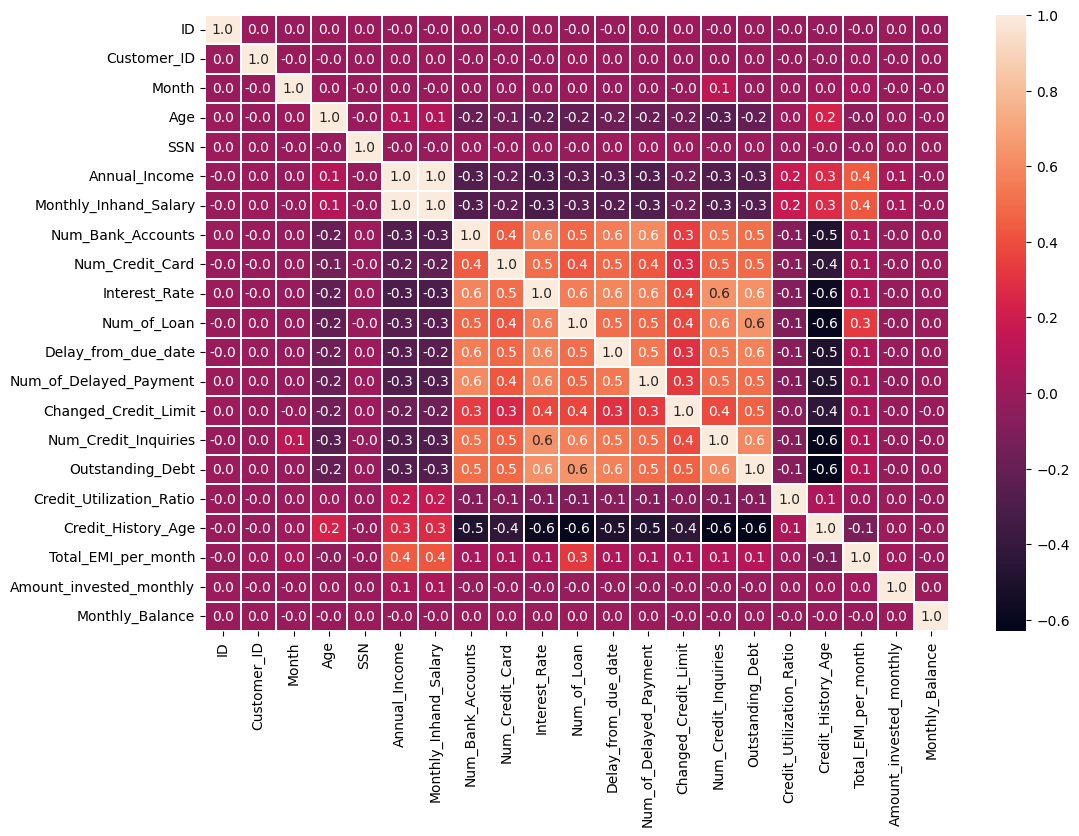

In [ ]:
def correlation_plot(df=df):
    plt.figure(figsize=[12,8])
    sns.heatmap(df.select_dtypes(exclude='object')
                .dropna().corr(),annot=True,
                fmt='.1f',linewidth=.2)

correlation_plot()

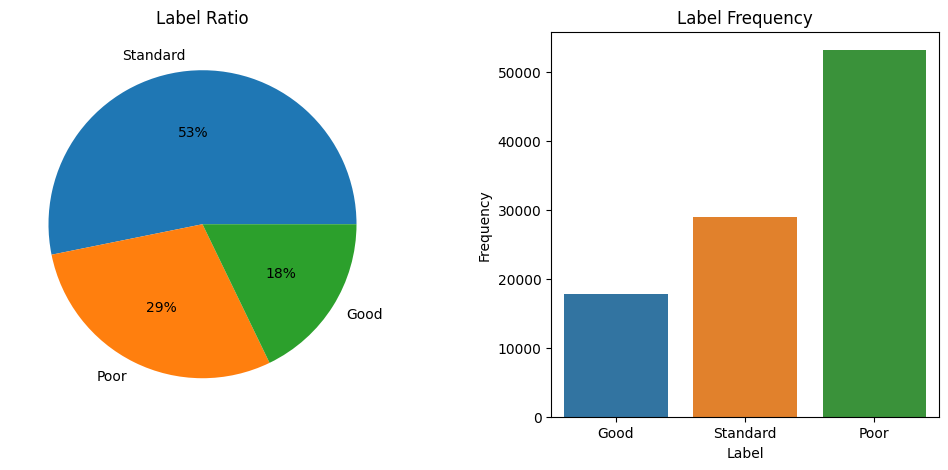

In [ ]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: Pie chart
def target_ratio(df, target='Credit_Score'):
    if not target:
        axes[0].pie(df.value_counts(), labels=df.value_counts().index, autopct='%.0f%%')
    else:
        axes[0].pie(df[target].value_counts(), labels=df[target].value_counts().index, autopct='%.0f%%')
    axes[0].set_title("Label Ratio")

target_ratio(df)

# Second subplot: Bar plot
group_sizes = df.groupby("Credit_Score").size()
sns.barplot(x=df.Credit_Score.unique(), y=group_sizes, ax=axes[1])
axes[1].set_title("Label Frequency")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Frequency")

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.4)

# Display the plots
plt.show()


# Chúng ta có thể thấy dataset bị mất cân bằng dữ liệu giữa các label
# Cụ thể số lượng instances có label là "Standard" có số lượng áp đảo so với hai label còn lại
# Việc mất cân bằng dữ liệu này có thể gây ra vấn đê trong quá trình train (hoặc evaluate) model do đó cần được chú ý

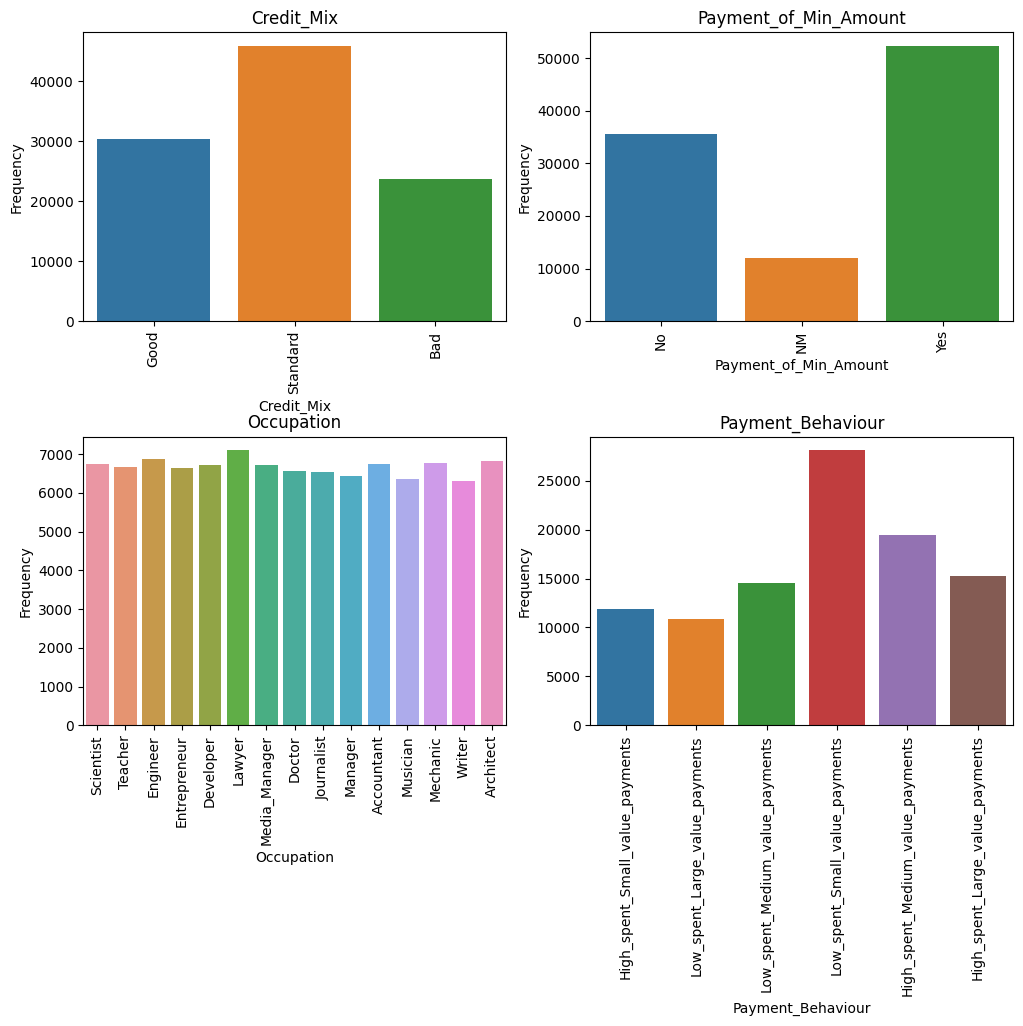

In [ ]:
n_col = 2
n_row = 2
cols = [["Credit_Mix", "Payment_of_Min_Amount"], ["Occupation", "Payment_Behaviour"]]

# Create subplots
fig, axs = plt.subplots(n_row, n_col, figsize=(12, 9))
plt.subplots_adjust(hspace=0.4)

# Iterate over rows and columns
for i in range(n_row):
    for j in range(n_col):
        # Use Seaborn's countplot
        sns.countplot(x=cols[i][j], data=df, ax=axs[i][j])

        axs[i][j].set_title(cols[i][j])
        axs[i][j].tick_params(axis='x', labelrotation=90)
        axs[i][j].set_ylabel('Frequency')

# Display the plot
plt.show()




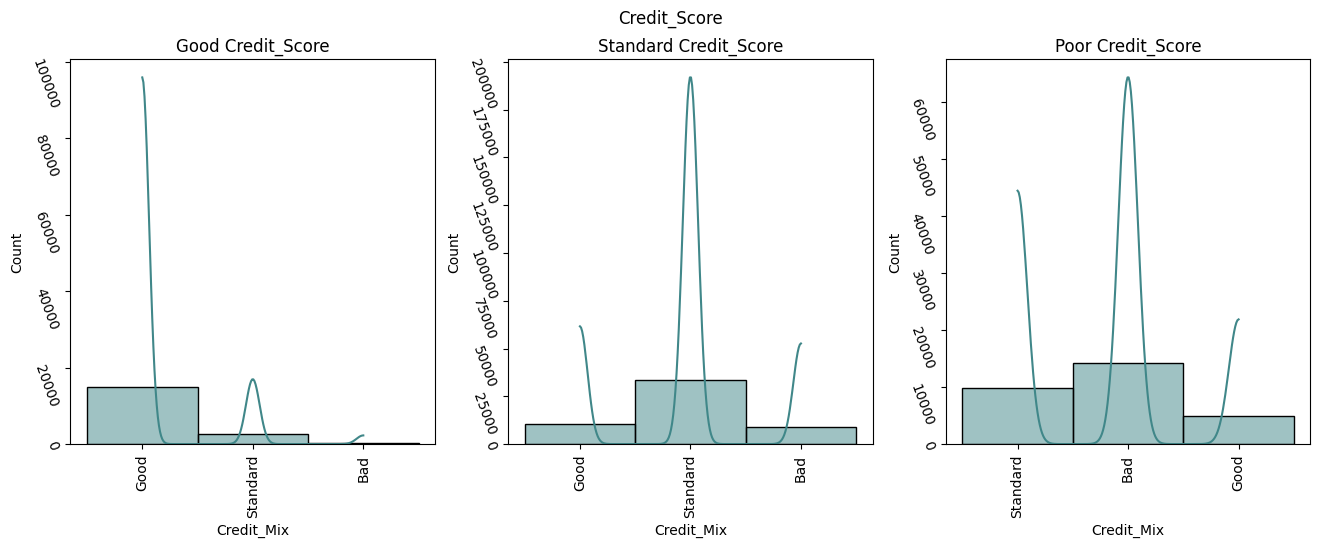

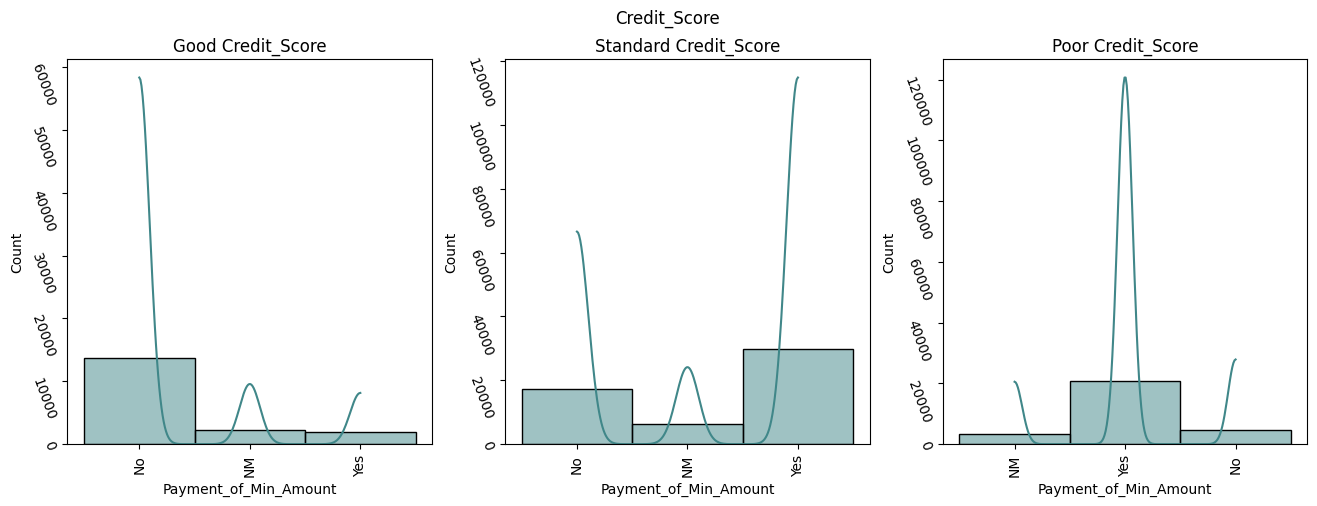

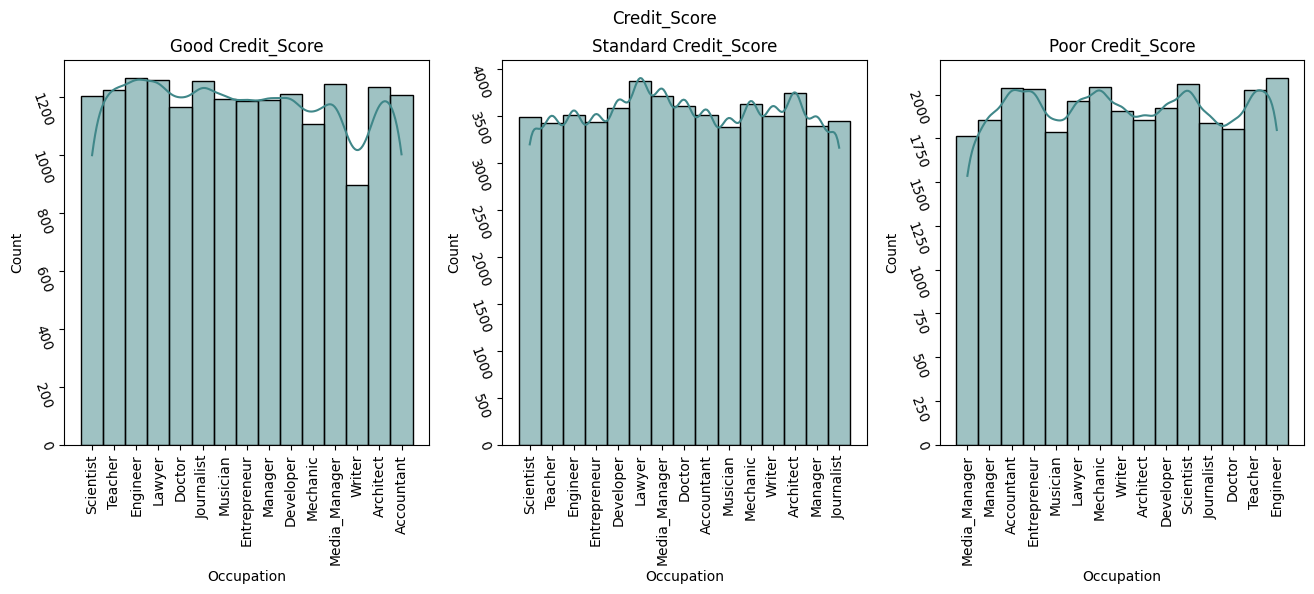

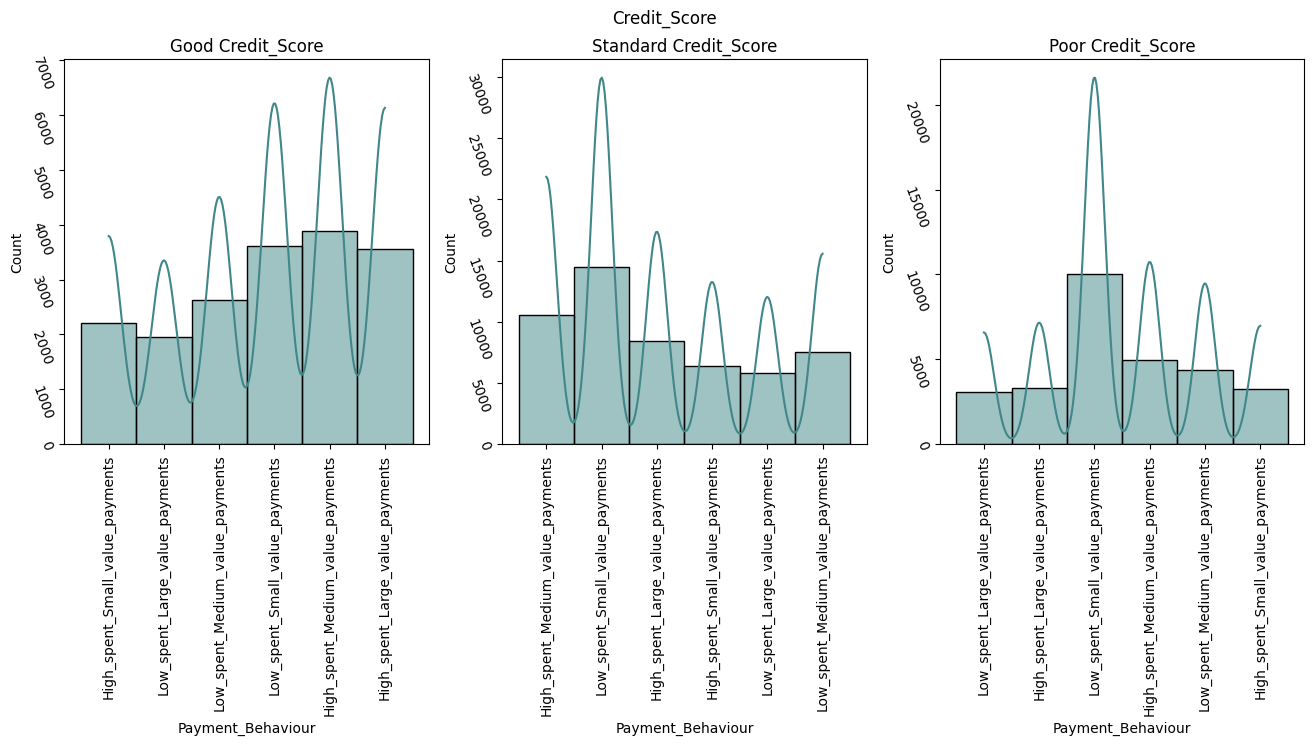

In [ ]:
features = ["Credit_Mix", "Payment_of_Min_Amount", "Occupation", "Payment_Behaviour"]
feature2 = 'Credit_Score'

bins = 30

for feature1 in features:
    if df[feature1].nunique() < 30:
        bins = df[feature1].nunique()

    _ = df[feature2].unique().tolist()
    col = len(_)
    if df[feature1].dtype != 'O':
        col += 1
    fig, axes = plt.subplots(1, col, sharey='none', figsize=[16, 5])

    fig.suptitle(f'{feature2}')
    for i, v in enumerate(_):
        # axes[i].invert_yaxis()  # Invert the y-axis
        axes[i].set_title(f'{v}\n{feature2}')
        axes[i].tick_params(axis='x', labelrotation=90)
        axes[i].tick_params(axis='y', labelrotation=-70)

        if df[feature1].dtype != 'O':
            if i == 0:
                sns.kdeplot(data=df[[feature1, feature2]],
                            x=feature1, hue=feature2,
                            ax=axes[0],
                            color='#408789')
                # axes[0].invert_yaxis()  # Invert the y-axis

        sns.histplot((df[feature1][df[feature2] == v]).dropna(),
                     bins=bins, ax=axes[i], kde=True, color='#408789')
        axes[i].set_title(f'{v} {feature2}')

plt.show()


In [ ]:
df.Type_of_Loan.unique()

# Type_of_Loan là danh sách các loại khoản vay của khách hàng
# Có thể tách cột này thành nhiều cột (có giá trị kiểu boolean) thể hiện cho từng loại khoản vay

array(['auto loan,credit-builder loan,personal loan,home equity loan',
       'credit-builder loan', 'auto loan,auto loan,not specified', ...,
       'home equity loan,auto loan,auto loan,auto loan',
       'payday loan,student loan,mortgage loan,not specified',
       'personal loan,auto loan,mortgage loan,student loan,student loan'],
      dtype=object)

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
len(numeric_cols)

21

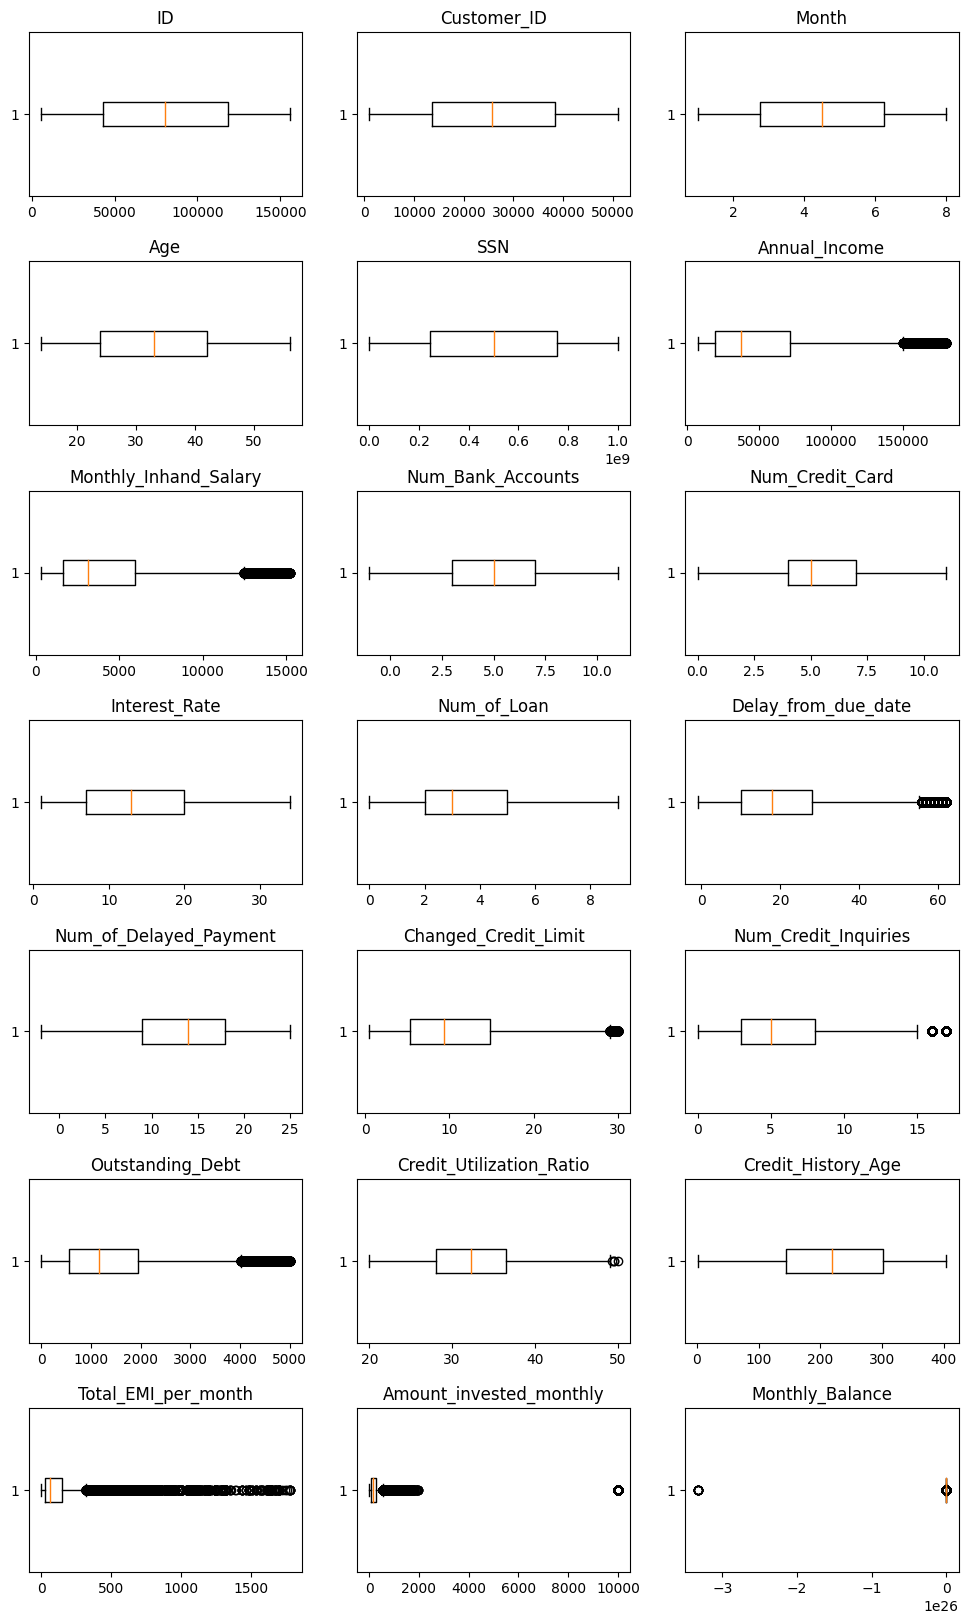

In [ ]:
numeric_cols = np.array(numeric_cols).reshape((7,3))
n_row = numeric_cols.shape[0]
n_col = numeric_cols.shape[1]

fig, axs = plt.subplots(n_row, n_col, figsize=(12,20))
plt.subplots_adjust(hspace=0.4)

for i in range(n_row):
  for j in range(n_col):
    axs[i][j].boxplot(df[numeric_cols[i][j]], vert=False)
    axs[i][j].set_title(numeric_cols[i][j])

# Dựa vào biểu đồ bên dưới chúng ta có thể thấy trong một số features tồn tại rất nhiều outliers
# Các features có nhiều outliers: Annual_Income, Monthly_Inhand_Salary, Delay_from_due_date,
# Outstanding_Debt, Total_EMI_per_month, Amount_invested_monthly, Monthly_Balance

In [ ]:
# Qua tìm hiểu có thể biết được EMI (Equated Monthly Installment) hiểu đơn giản
# tiền trả góp hàng tháng của khách hàng, khi khách hàng chi tiêu càng nhiều thì
# ắt EMI sẽ càng cao. Thông thường tại các ngân hàng EMI sẽ đi kèm với một số điều
# khoản và lãi suất nhất định. Do đó một người EMI có EMI rất cao có nghĩa người đó
# đã chi tiêu rất nhiều và gánh nặng tài chính hàng tháng của người đó cũng tăng
# lên.
# Như vậy EMI là một feature thích hợp để dự đoán Credit Score
# Việc có nhiều outliers ở cột EMI có thể do sự khác nhau về hành vi tiêu dùng giữa
# các khách hàng.

print(df.Total_EMI_per_month.describe())
print()
print(df.Monthly_Inhand_Salary.describe())

# Nếu một người có EMI đáng kể so với thu nhập hàng tháng của họ, đây có thể là
# dấu hiệu của một người đang gặp khó khăn về tài chính
# Do đó để đánh giá chính xác hơn tính hình tài chính của một người không nên chỉ dựa
# vào EMI mà còn cần xem xét đến thu nhập của người đó
# Vì vậy cần có một feature mới để thể hiện cho sự tương quan giữa EMI và thu nhập
# của một người. Chúng ta sẽ sử dụng tỷ lệ giữa EMI và thu nhập hàng tháng để
# thể hiện điều này.

df["EMI_Income_Ratio"] = df.Total_EMI_per_month /  df.Monthly_Inhand_Salary
print()
print(df.EMI_Income_Ratio.describe())

count    100000.000000
mean        107.699208
std         132.267056
min           0.000000
25%          29.268886
50%          66.462304
75%         147.392573
max        1779.103254
Name: Total_EMI_per_month, dtype: float64

count    100000.000000
mean       4197.270835
std        3186.432497
min         303.645417
25%        1626.594167
50%        3095.905000
75%        5957.715000
max       15204.633333
Name: Monthly_Inhand_Salary, dtype: float64

count    100000.000000
mean          0.029797
std           0.031453
min           0.000000
25%           0.012129
50%           0.024409
75%           0.040346
max           1.979212
Name: EMI_Income_Ratio, dtype: float64


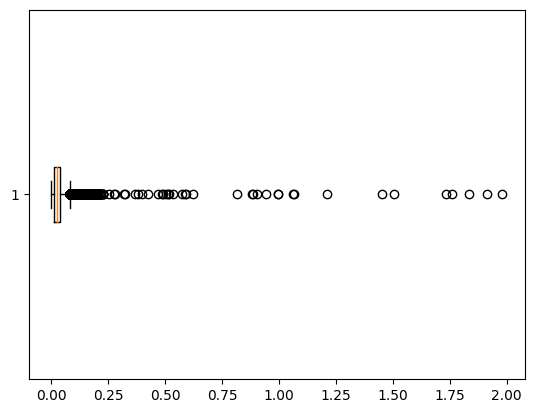

In [ ]:
plt.boxplot(df.EMI_Income_Ratio, vert=False);

                       Annual_Income  Monthly_Inhand_Salary
Annual_Income               1.000000               0.998154
Monthly_Inhand_Salary       0.998154               1.000000



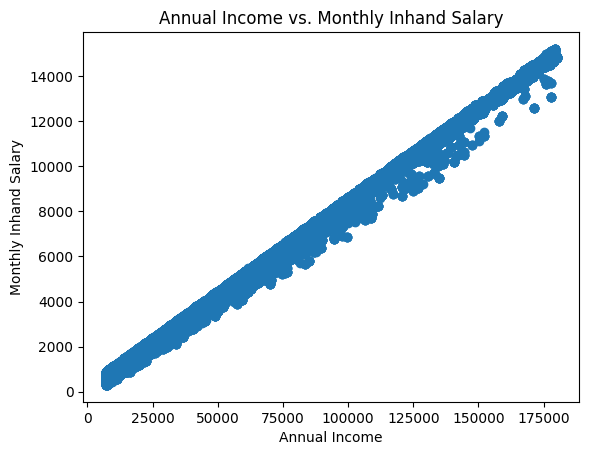

In [ ]:
# Chúng ta có thể thấy Annual_Income (thu nhập hằng năm) và Monthly_Inhand_Salary
# (lương hằng tháng) đều có nhiều outliers. Tuy nhiên việc này có thể giải thích
# do sự khác biệt về thu nhập giữa các khách hàng. Theo đó sẽ có một số cá nhân có thu
# nhập cao đáng kể so với những người còn lại

# Ngoài ra, chúng ta có thể dễ dàng thấy được Annual_Income có một mối quan hệ chặt
# chẽ với với Monthly_Inhand_Salary, cụ thể hai giá trị này sẽ có xu hướng tỷ lệ thuận
# với nhau. Như vậy, liệu chú ta có thể sử dụng một trong hai giá trị này để đại
# diện cho giá trị còn lại?

print(df[["Annual_Income", "Monthly_Inhand_Salary"]].corr())
print()

# Với correlation xấp xỉ bằng 1.0 chúng ta có thể chắc chắn về mối quan hệ đồng biến
# giữa Annual_Income và Monthly_Inhand_Salary

plt.scatter(df.Annual_Income, df.Monthly_Inhand_Salary)
plt.xlabel("Annual Income")
plt.ylabel("Monthly Inhand Salary")
plt.title("Annual Income vs. Monthly Inhand Salary")
plt.show()

# Dựa vào biểu đồ bên dưới có thể thấy là có một số khách hàng có các khoản thu nhập
# theo năm. Do đó nếu chỉ sử dụng Annual_Income hoặc Monthly_Inhand_Salary có thể
# sẽ không đánh giá đúng được năng lực tài chính của một người, dó đó chúng ta
# cần phải xem xét cả hai giá trị này

## Preprocessing

In [ ]:
type_of_loan_values = df['Type_of_Loan'].unique()
unique_type_of_loan = set()
for types in type_of_loan_values:
  unique_type_of_loan.update(types.split(","))

new_df = pd.DataFrame.from_dict({type_loan: [0] * df.shape[0] for type_loan in unique_type_of_loan})
df = pd.concat((df, new_df), axis=1)

for row in df.iterrows():
  df.loc[row[0], list(unique_type_of_loan)] = np.isin(list(unique_type_of_loan),
                                                      row[1].Type_of_Loan.split(","),
                                                      assume_unique=True).astype(int)

df.drop(columns=['Type_of_Loan','ID', 'Name', 'SSN', 'Customer_ID'], inplace=True)
df.shape

(100000, 34)

In [ ]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,personal loan,student loan,auto loan,not specified,home equity loan,credit-builder loan,debt consolidation loan,payday loan,No Data,mortgage loan
0,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,1,0,1,0,1,1,0,0,0,0
1,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,-1.0,...,1,0,1,0,1,1,0,0,0,0
2,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,3.0,...,1,0,1,0,1,1,0,0,0,0
3,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,5.0,...,1,0,1,0,1,1,0,0,0,0
4,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,6.0,...,1,0,1,0,1,1,0,0,0,0


In [ ]:
non_numerical_columns = df.select_dtypes(exclude=[np.number]).columns

for column in non_numerical_columns:
  df[column] = LabelEncoder().fit_transform(df[column])

## Save preprocessed data to csv file

In [ ]:
col_to_move = df.pop('Credit_Score')
df.insert(len(df.columns), 'Credit_Score', col_to_move)

df.to_csv('clean_credit_score.csv', index=False)